In [1]:
print("Tokenizer 🚀")

Tokenizer 🚀


In [2]:
from transformers import AutoTokenizer

In [3]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")   # encoder-only

In [4]:
from transformers import AutoTokenizer

# ── 1. BERT (bert-base-uncased) ───────────────────────────────────────────────
# WordPiece tokenizer | lowercase | 30,522 vocab | adds [CLS] and [SEP] tokens
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

text = "Hello, I am learning Transformers!"

tokens     = tokenizer.tokenize(text)
encoded    = tokenizer(text, return_tensors="pt")
decoded    = tokenizer.decode(encoded["input_ids"][0])

print("Tokens  :", tokens)
# ['hello', ',', 'i', 'am', 'learning', 'transform', '##ers', '!']

print("input_ids :", encoded["input_ids"])
# tensor([[  101,  7592,  1010,  1045,  2572,  4083, 19081,  2015,   999,   102]])

print("Decoded :", decoded)
# [CLS] hello, i am learning transformers! [SEP]

Tokens  : ['hello', ',', 'i', 'am', 'learning', 'transformers', '!']
input_ids : tensor([[  101,  7592,  1010,  1045,  2572,  4083, 19081,   999,   102]])
Decoded : [CLS] hello, i am learning transformers! [SEP]


In [6]:
from transformers import AutoTokenizer

# ── BERT TOKENIZER (bert-base-uncased) ───────────────────────────────────────
# Algorithm    : WordPiece — greedy longest-match subword splitting
# Vocab size   : 30,522 tokens (words + subwords + special tokens)
# Case         : uncased — all input lowercased before any processing
# Special tokens added by __call__():
#   [CLS] = 101  → prepended  — sentence-level representation for classification
#   [SEP] = 102  → appended   — marks end of sequence / boundary between two sentences
# Subword marker : "##" prefix on continuation pieces
#   e.g. "transformers" → "transform" + "##ers"
#   "##" means "this piece is NOT a word start, it continues the previous piece"
# attention_mask : 1 for every real token, 0 for padding (padding absent here)
# ─────────────────────────────────────────────────────────────────────────────

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
text = "Hello, I am learning Transformers!"

# tokenize() → raw subword pieces only
# does NOT add [CLS]/[SEP], does NOT return IDs, does NOT return tensors
tokens = tokenizer.tokenize(text)

# __call__() → full pipeline in one shot:
#   lowercase → WordPiece split → prepend [CLS] → append [SEP] → convert to IDs → tensor
encoded = tokenizer(text, return_tensors="pt")

# decode() → ID list back to human-readable string
# by default keeps [CLS] and [SEP] visible
# pass skip_special_tokens=True to strip them
decoded = tokenizer.decode(encoded["input_ids"][0])


# ── WORDPIECE ALGORITHM (how splitting works internally) ─────────────────────
# 1. Lowercase the full string (uncased model only)
# 2. Split on whitespace and punctuation → raw words
# 3. For each word, greedily find the longest prefix that exists in vocab
#    - If the full word is in vocab → single token
#    - If not → take longest known prefix, mark the rest with "##", repeat
# 4. If no valid split found → replace with [UNK] token (id=100)
# Precondition : input must be a plain string (not pre-tokenized)
# Time  : O(n · L²) where n = words, L = max word length (greedy search per word)
# Space : O(V) where V = vocab size (30,522 entries loaded into memory)


# ── PIPELINE STAGES AND METHOD MAPPING ───────────────────────────────────────
# tokenizer.tokenize(text)        → Stage 1+2 only (lowercase + split), no IDs
# tokenizer(text)  / __call__()   → Full pipeline: Stage 1→2→3→4 + tensors
# tokenizer.encode(text)          → Same as __call__ but returns plain list of IDs
# tokenizer.decode(ids)           → Reverse: IDs → string, joins "##" pieces
# tokenizer.convert_tokens_to_ids → Stage 3 only (tokens → IDs, no specials added)


# ── DRY RUN : text = "Hello, I am learning Transformers!" ────────────────────

# Stage 1 — Lowercase (uncased model strips case before anything else)
# "Hello, I am learning Transformers!"
#  →  "hello, i am learning transformers!"

# Stage 2 — tokenizer.tokenize() : WordPiece split, no specials, no IDs
# word          pieces              reason
# hello      →  hello               whole word in vocab
# ,          →  ,                   punctuation split by BasicTokenizer
# i          →  i                   whole word in vocab
# am         →  am                  whole word in vocab
# learning   →  learning            whole word in vocab
# transformers→ transform + ##ers   "transformers" not in vocab
#                                   "transform" is longest known prefix
#                                   "ers" gets "##" marker → ##ers
# !          →  !                   punctuation split
#
# tokens = ['hello', ',', 'i', 'am', 'learning', 'transform', '##ers', '!']

# Stage 3 — tokenizer() : add specials + convert to IDs
# pos  token       id
#  0   [CLS]      101    ← always prepended
#  1   hello     7592
#  2   ,         1010
#  3   i         1045
#  4   am        2572
#  5   learning  4083
#  6   transform 19081
#  7   ##ers     2015
#  8   !          999
#  9   [SEP]      102    ← always appended
#
# encoded["input_ids"]      = tensor([[101, 7592, 1010, 1045, 2572, 4083, 19081, 2015, 999, 102]])
# encoded["attention_mask"] = tensor([[  1,    1,    1,    1,    1,    1,     1,    1,   1,   1]])
# encoded["token_type_ids"] = tensor([[  0,    0,    0,    0,    0,    0,     0,    0,   0,   0]])
# all zeros → single sentence (segment A); segment B would be all 1s

# Stage 4 — tokenizer.decode() : IDs → string, "##" pieces joined, specials visible
# 101   → [CLS]       (kept by default, pass skip_special_tokens=True to strip)
# 7592  → hello
# 1010  → ,
# 1045  → i
# 2572  → am
# 4083  → learning
# 19081 → transform ─┐
# 2015  → ##ers     ─┘  joined → "transformers"  (## stripped, no space inserted)
# 999   → !
# 102   → [SEP]       (kept by default)
#
# decoded = "[CLS] hello, i am learning transformers! [SEP]"

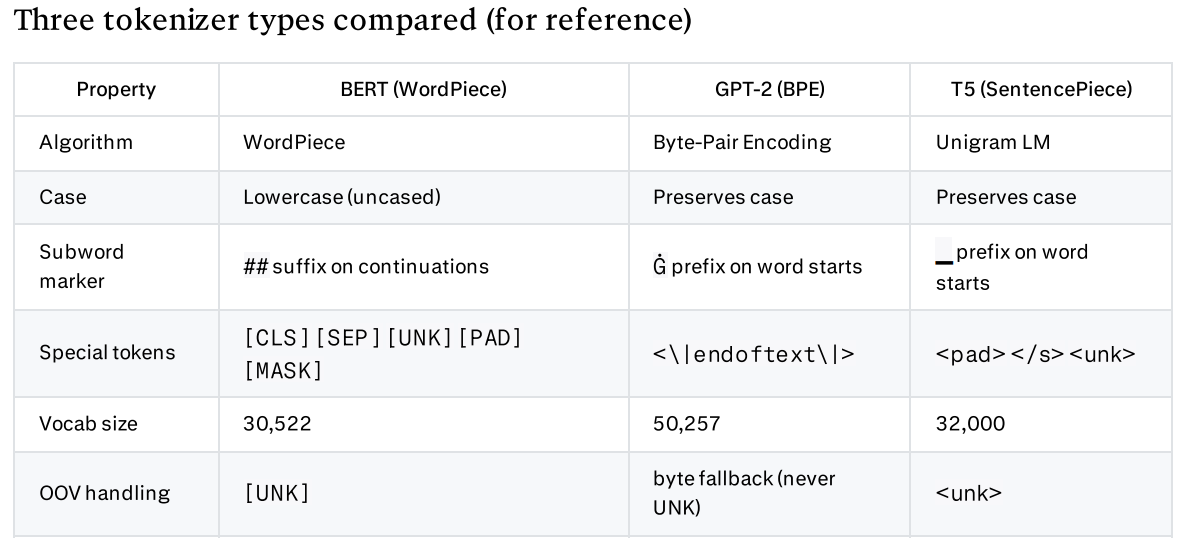

In [5]:

# ── 2. RoBERTa (roberta-base) ─────────────────────────────────────────────────
# BPE tokenizer | case-sensitive | 50,265 vocab | uses Ġ for space prefix
# Key diff from BERT: NO [CLS]/[SEP] — uses <s> and </s> instead
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

text = "Hello, I am learning Transformers!"

tokens  = tokenizer.tokenize(text)
encoded = tokenizer(text, return_tensors="pt")
decoded = tokenizer.decode(encoded["input_ids"][0])

print("Tokens  :", tokens)
# ['Hello', ',', 'ĠI', 'Ġam', 'Ġlearning', 'ĠTransformers', '!']

print("input_ids :", encoded["input_ids"])
# tensor([[    0, 31414,     6,    38,   524,  2239, 44091,   328,     2]])

print("Decoded :", decoded)
# <s>Hello, I am learning Transformers!</s>

# NOTE: Ġ = space before a word (BPE space prefix convention)

Tokens  : ['Hello', ',', 'ĠI', 'Ġam', 'Ġlearning', 'ĠTransformers', '!']
input_ids : tensor([[    0, 31414,     6,    38,   524,  2239, 34379,   328,     2]])
Decoded : <s>Hello, I am learning Transformers!</s>


In [ ]:
from transformers import AutoTokenizer

# ── ROBERTA TOKENIZER (roberta-base) ─────────────────────────────────────────
# Algorithm    : Byte-Pair Encoding (BPE) — merges frequent character pairs
# Vocab size   : 50,265 tokens (larger than BERT)
# Case         : case-sensitive — preserves original casing ("Hello" ≠ "hello")
# Special tokens added by __call__():
#   <s>  = 0  → prepended  — start of sequence (similar to [CLS])
#   </s> = 2  → appended   — end of sequence (similar to [SEP])
# Subword marker : "Ġ" (U+0120) prefix indicates a space before the word
#   e.g. "Hello world" → "Hello", "Ġworld"
#   "Ġ" means "this token starts after a space"
# attention_mask : 1 for real tokens, 0 for padding (no padding here)
# token_type_ids : NOT used in RoBERTa (always omitted or None)
# ─────────────────────────────────────────────────────────────────────────────

tokenizer = AutoTokenizer.from_pretrained("roberta-base")
text = "Hello, I am learning Transformers!"

# tokenize() → BPE subword pieces only
# does NOT add <s>/</s>, does NOT return IDs, does NOT return tensors
tokens = tokenizer.tokenize(text)

# __call__() → full pipeline:
#   byte-level split → BPE merge → add <s>, </s> → convert to IDs → tensor
encoded = tokenizer(text, return_tensors="pt")

# decode() → ID list back to string
# keeps <s>, </s> by default (use skip_special_tokens=True to remove)
decoded = tokenizer.decode(encoded["input_ids"][0])


# ── BPE ALGORITHM (how splitting works internally) ───────────────────────────
# 1. Input is converted to byte-level representation (handles any Unicode)
# 2. Frequent character pairs are merged iteratively (learned merges)
# 3. Space is encoded explicitly using "Ġ" prefix
#    - "word"  → no space before
#    - "Ġword" → space before word
# 4. Unknown words are NOT replaced with [UNK] easily (byte-level fallback exists)
# Precondition : raw string input (no manual token splitting required)
# Time  : O(n · merges)  (depends on merge rules)
# Space : O(V) where V = 50,265 vocab


# ── PIPELINE STAGES AND METHOD MAPPING ───────────────────────────────────────
# tokenizer.tokenize(text)        → BPE split only (no specials, no IDs)
# tokenizer(text) / __call__()    → Full pipeline: BPE → specials → IDs → tensors
# tokenizer.encode(text)          → Same as __call__ but returns list of IDs
# tokenizer.decode(ids)           → IDs → string, removes "Ġ" by adding spaces
# tokenizer.convert_tokens_to_ids → tokens → IDs only


# ── DRY RUN : text = "Hello, I am learning Transformers!" ────────────────────

# Stage 1 — No lowercasing (case preserved)
# "Hello, I am learning Transformers!"

# Stage 2 — tokenizer.tokenize() : BPE split
# token              meaning
# Hello           →  "Hello"           (start of sentence, no space prefix)
# ,               →  ","               (punctuation)
# ĠI              →  " I"              (space + I)
# Ġam             →  " am"
# Ġlearning       →  " learning"
# ĠTransformers  →  " Transformers"   (full word exists in vocab → no split)
# !               →  "!"
#
# tokens = ['Hello', ',', 'ĠI', 'Ġam', 'Ġlearning', 'ĠTransformers', '!']


# Stage 3 — tokenizer() : add specials + convert to IDs
# pos  token           id
#  0   <s>              0
#  1   Hello        31414
#  2   ,                6
#  3   ĠI              38
#  4   Ġam            524
#  5   Ġlearning     2239
#  6   ĠTransformers 44091
#  7   !              328
#  8   </s>             2
#
# encoded["input_ids"] =
# tensor([[    0, 31414,     6,    38,   524,  2239, 44091,   328,     2]])
#
# encoded["attention_mask"] =
# tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1]])
#
# encoded["token_type_ids"] = None  (RoBERTa does not use segment IDs)


# Stage 4 — tokenizer.decode() : IDs → string
# 0      → <s>
# 31414  → Hello
# 6      → ,
# 38     → ĠI          → " I"
# 524    → Ġam         → " am"
# 2239   → Ġlearning   → " learning"
# 44091  → ĠTransformers → " Transformers"
# 328    → !
# 2      → </s>
#
# decoded = "<s>Hello, I am learning Transformers!</s>"

In [ ]:
from transformers import AutoTokenizer

# ── GPT-2 TOKENIZER (gpt2) ───────────────────────────────────────────────────
# Algorithm    : Byte-Pair Encoding (BPE) — byte-level merges (same family as RoBERTa)
# Vocab size   : 50,257 tokens
# Case         : case-sensitive — preserves original casing
# Special tokens:
#   GPT-2 does NOT automatically add start/end tokens during encoding
#   eos_token = 50256  → used as end-of-sequence (optional, not auto-added)
#   pad_token = None   → must be manually set for batching
# Subword marker : "Ġ" prefix indicates a space before the word (like RoBERTa)
#   e.g. "Hello world" → "Hello", "Ġworld"
# attention_mask : 1 for real tokens, 0 for padding (padding absent here)
# token_type_ids : NOT used (decoder-only architecture)
# ─────────────────────────────────────────────────────────────────────────────

tokenizer = AutoTokenizer.from_pretrained("gpt2")

# GPT-2 has NO pad token → must assign manually for batching
tokenizer.pad_token = tokenizer.eos_token

text = "Hello, I am learning Transformers!"

# tokenize() → BPE pieces only (no specials, no IDs)
tokens = tokenizer.tokenize(text)

# __call__() → full pipeline:
#   byte-level BPE → convert to IDs → tensor
#   (NO <s>, </s>, [CLS], [SEP] added)
encoded = tokenizer(text, return_tensors="pt")

# decode() → IDs → string (restores spaces from "Ġ")
decoded = tokenizer.decode(encoded["input_ids"][0])


# ── BPE ALGORITHM (byte-level, GPT-2 style) ──────────────────────────────────
# 1. Convert text into byte-level representation (covers all Unicode)
# 2. Apply learned merge rules to combine frequent byte pairs
# 3. Space handled explicitly using "Ġ"
# 4. No [UNK] — every input can be represented via bytes
# Precondition : raw string input
# Time  : O(n · merges)
# Space : O(V) where V = 50,257


# ── PIPELINE STAGES AND METHOD MAPPING ───────────────────────────────────────
# tokenizer.tokenize(text)        → BPE split only (no IDs)
# tokenizer(text) / __call__()    → BPE → IDs → tensors (no special tokens)
# tokenizer.encode(text)          → same but returns list of IDs
# tokenizer.decode(ids)           → IDs → string, reconstructs spaces
# tokenizer.convert_tokens_to_ids → tokens → IDs only


# ── DRY RUN : text = "Hello, I am learning Transformers!" ────────────────────

# Stage 1 — No lowercasing (case preserved)
# "Hello, I am learning Transformers!"

# Stage 2 — tokenizer.tokenize() : BPE split
# token              meaning
# Hello           →  "Hello"
# ,               →  ","
# ĠI              →  " I"
# Ġam             →  " am"
# Ġlearning       →  " learning"
# ĠTransform      →  " Transform"
# ers             →  continuation (no Ġ → no leading space)
# !               →  "!"
#
# tokens = ['Hello', ',', 'ĠI', 'Ġam', 'Ġlearning', 'ĠTransform', 'ers', '!']


# Stage 3 — tokenizer() : convert to IDs (NO special tokens added)
# pos  token           id
#  0   Hello        15496
#  1   ,               11
#  2   ĠI             314
#  3   Ġam            716
#  4   Ġlearning     4673
#  5   ĠTransform   48108
#  6   ers             68
#  7   !                0
#
# encoded["input_ids"] =
# tensor([[15496,    11,   314,   716,  4673, 48108,    68,     0]])
#
# encoded["attention_mask"] =
# tensor([[1, 1, 1, 1, 1, 1, 1, 1]])
#
# encoded["token_type_ids"] = None  (not used)


# Stage 4 — tokenizer.decode() : IDs → string
# 15496 → Hello
# 11    → ,
# 314   → ĠI         → " I"
# 716   → Ġam        → " am"
# 4673  → Ġlearning  → " learning"
# 48108 → ĠTransform → " Transform"
# 68    → ers        → joins → "Transformers"
# 0     → !
#
# decoded = "Hello, I am learning Transformers!"


# ── IMPORTANT NOTES (GPT-2 SPECIFIC) ─────────────────────────────────────────
# • No automatic special tokens → model is purely causal (left-to-right)
# • eos_token (50256) must be added manually if needed:
#     tokenizer(text, add_special_tokens=True)  # still may not add like BERT
# • Padding must be explicitly handled:
#     tokenizer(texts, padding=True, return_tensors="pt")
# • Same tokenizer family as RoBERTa, but behavior differs in:
#     - No <s>, </s>
#     - No classification token
#     - Designed for generation, not classification